# Rolling Stationarity Module Check — Stable-Economy Baseline

This notebook validates `rolling_stationarity.py` on the May 8–12, 2023 non-conflict Brent–WTI baseline. It uses a 30-observation window refreshed every minute and runs each trading date separately so windows do not cross overnight boundaries.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rolling_stationarity import rolling_stationarity_test

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
DATA_PATH = PROJECT_ROOT / "_data" / "event_windows" / "non_conflict_baseline_2023_cl_bz_1m_2023-05-08_2023-05-14.parquet"
df = pd.read_parquet(DATA_PATH).sort_index()
spread = df["synth_mid"].dropna()

pd.DataFrame({
    "observations": [len(spread)],
    "start": [spread.index.min()],
    "end": [spread.index.max()],
    "trading_dates": [spread.index.normalize().nunique()],
    "mean": [spread.mean()],
    "standard_deviation": [spread.std()],
})

,observations,start,end,trading_dates,mean,standard_deviation
0,4858,2023-05-08 00:00:00+00:00,2023-05-12 20:59:00+00:00,5,-3.879286,0.124229


## Overlapping 30-Minute Stationarity Test

The test advances one observation at a time. A window is stationary only when ADF rejects a unit root and KPSS does not reject level stationarity.

In [3]:
daily_results = []
for trading_date, daily_spread in spread.groupby(spread.index.normalize()):
    result = rolling_stationarity_test(daily_spread, window=30, step=1)
    result["trading_date"] = trading_date.date().isoformat()
    daily_results.append(result)

results = pd.concat(daily_results).sort_index()
results.head()

,window_start,n_observations,adf_pvalue,kpss_pvalue,passes_adf,passes_kpss,is_stationary,valid_test,error,trading_date
window_end,,,,,,,,,,
2023-05-08 01:22:00+00:00,2023-05-08 00:00:00+00:00,30,0.620323,0.017295,False,False,False,True,None,2023-05-08
2023-05-08 01:23:00+00:00,2023-05-08 00:01:00+00:00,30,0.403562,0.019219,False,False,False,True,None,2023-05-08
2023-05-08 01:24:00+00:00,2023-05-08 00:04:00+00:00,30,0.499108,0.012199,False,False,False,True,None,2023-05-08
2023-05-08 01:25:00+00:00,2023-05-08 00:05:00+00:00,30,0.081934,0.018874,False,False,False,True,None,2023-05-08
2023-05-08 01:27:00+00:00,2023-05-08 00:06:00+00:00,30,0.090855,0.020724,False,False,False,True,None,2023-05-08


In [4]:
summary_by_date = results.groupby("trading_date").agg(
    tested_windows=("valid_test", "sum"),
    stationary_windows=("is_stationary", "sum"),
)
summary_by_date["pass_rate"] = summary_by_date["stationary_windows"] / summary_by_date["tested_windows"]

overall = pd.DataFrame({
    "tested_windows": [results["valid_test"].sum()],
    "stationary_windows": [results["is_stationary"].sum()],
    "pass_rate": [results["is_stationary"].sum() / results["valid_test"].sum()],
}, index=["ALL DATES"])

summary_table = pd.concat([summary_by_date, overall])
summary_table.style.format({"pass_rate": "{:.1%}"}).set_caption("30-minute rolling stationarity pass rate")

,tested_windows,stationary_windows,pass_rate
2023-05-08,915,428,46.8%
2023-05-09,918,590,64.3%
2023-05-10,930,405,43.5%
2023-05-11,967,498,51.5%
2023-05-12,983,516,52.5%
ALL DATES,4713,2437,51.7%


## Stationary Signals Over Time

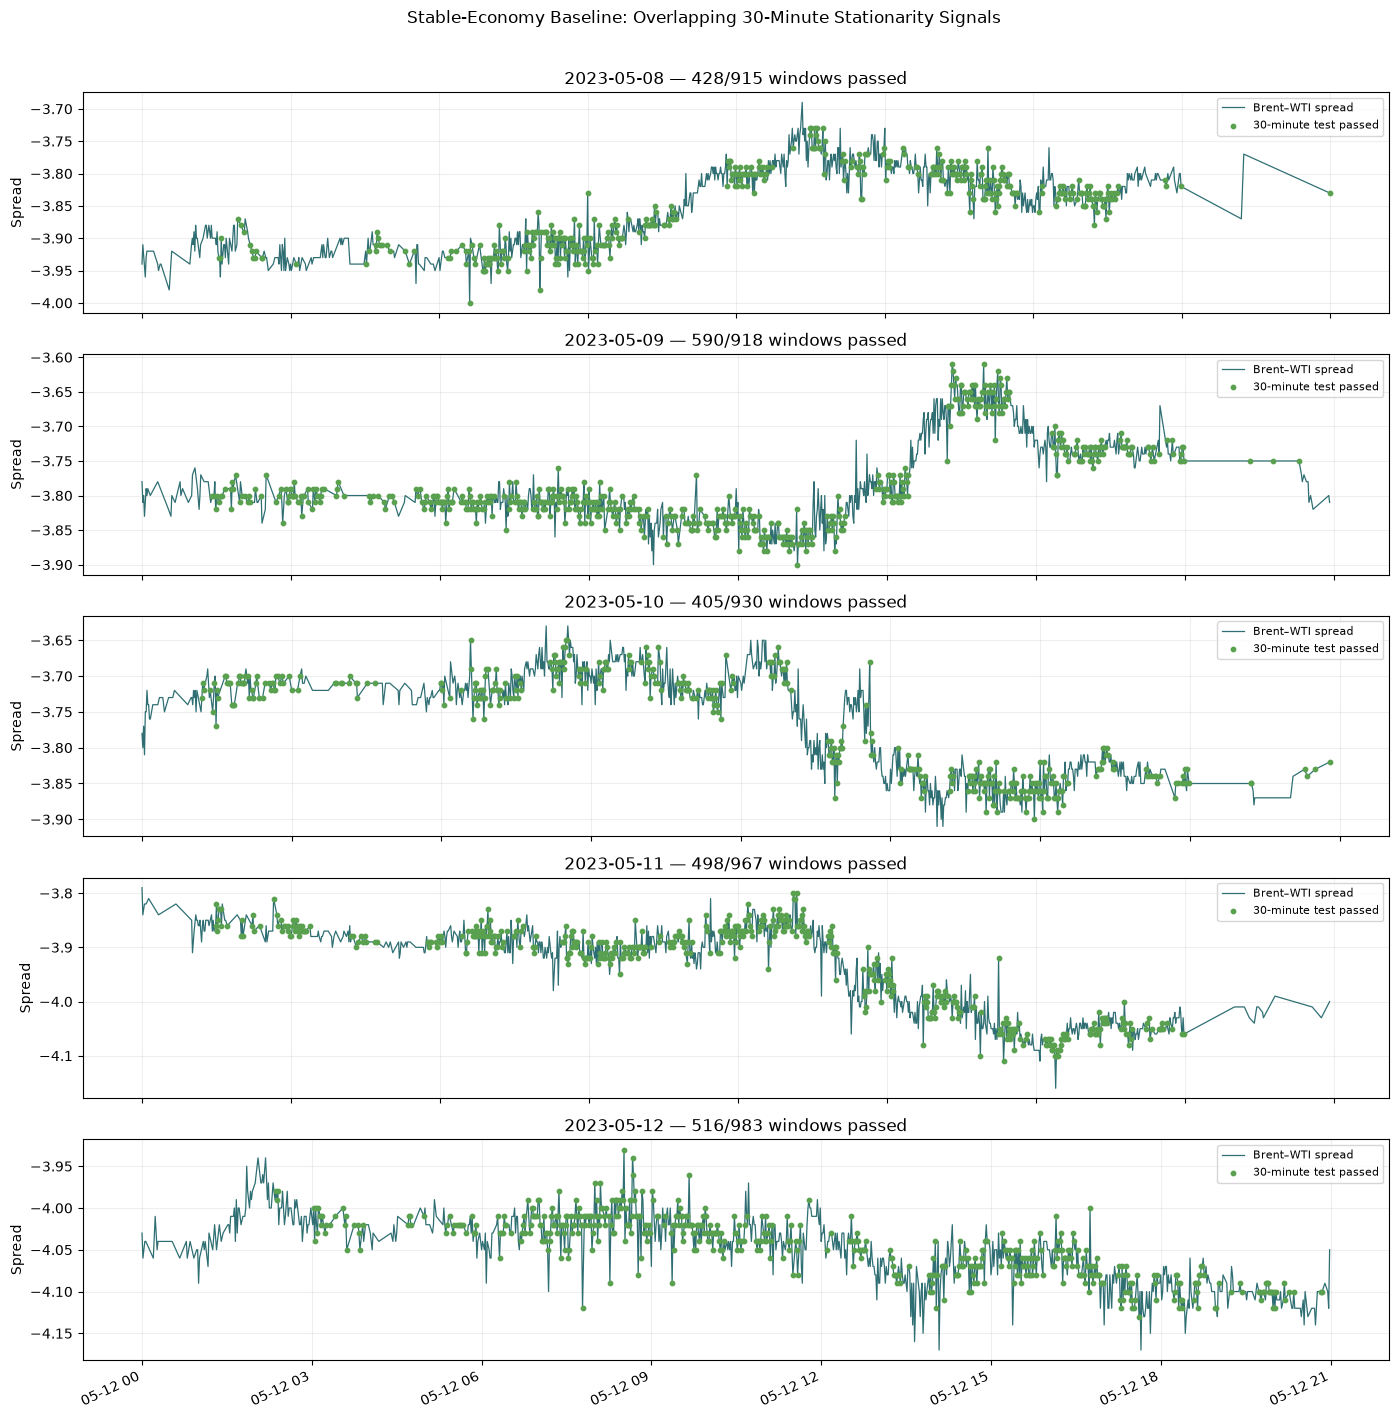

In [5]:
dates = list(spread.groupby(spread.index.normalize()).groups)
fig, axes = plt.subplots(len(dates), 1, figsize=(14, 2.8 * len(dates)), squeeze=False)

for ax, trading_date in zip(axes.flat, dates):
    daily_spread = spread[spread.index.normalize() == trading_date]
    daily_results_view = results[results["trading_date"] == trading_date.date().isoformat()]
    passing = daily_results_view[daily_results_view["is_stationary"]]

    ax.plot(daily_spread.index, daily_spread, color="#2F6F73", linewidth=0.9, label="Brent–WTI spread")
    ax.scatter(
        passing.index,
        daily_spread.reindex(passing.index),
        color="#59A14F",
        s=10,
        label="30-minute test passed",
        zorder=3,
    )
    ax.set_title(f"{trading_date.date()} — {len(passing)}/{len(daily_results_view)} windows passed")
    ax.set_ylabel("Spread")
    ax.grid(alpha=0.2)
    ax.legend(loc="best", fontsize=8)

fig.suptitle("Stable-Economy Baseline: Overlapping 30-Minute Stationarity Signals", y=1.01)
fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.show()

## Interpretation

This is a functional validation on a relatively stable, non-conflict period—not proof that the spread is always stationary in stable economies. Adjacent results are highly correlated because consecutive windows share 29 of 30 observations.